In [1]:
# 라이브러리 임포트
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 차트 설정
plt.style.use('seaborn-v0_8')
%matplotlib inline

print("라이브러리 로드 완료!")

라이브러리 로드 완료!


In [2]:
# 보유 종목 및 수량 입력
portfolio = {
    'JEPI':  120.25,
    'SCHD':  233.46,
    'PDBC':  391.58,
    'TSLA':  18.22,
    'CRCL':  55.25,  # 써클 인터넷 그룹
}

# 데이터 수집 기간
start_date = '2024-01-01'
end_date   = '2025-04-12'

# 주가 데이터 다운로드
tickers = list(portfolio.keys())
prices = yf.download(tickers, start=start_date, end=end_date)['Close']

print(prices.tail())

[**********************80%*************          ]  4 of 5 completed$CRCL: possibly delisted; no price data found  (1d 2024-01-01 -> 2025-04-12) (Yahoo error = "Data doesn't exist for startDate = 1704085200, endDate = 1744430400")
[*********************100%***********************]  5 of 5 completed

1 Failed download:
['CRCL']: possibly delisted; no price data found  (1d 2024-01-01 -> 2025-04-12) (Yahoo error = "Data doesn't exist for startDate = 1704085200, endDate = 1744430400")


Ticker      CRCL       JEPI       PDBC       SCHD        TSLA
Date                                                         
2025-04-07   NaN  47.771145  12.032856  24.012373  233.289993
2025-04-08   NaN  47.026302  11.753694  23.415432  221.860001
2025-04-09   NaN  50.391884  12.235008  24.907784  272.200012
2025-04-10   NaN  49.159679  12.042482  24.041258  252.399994
2025-04-11   NaN  49.637852  12.215755  24.358982  252.309998


In [3]:
# CRCL 티커 확인
crcl = yf.Ticker('CRCL')
print(crcl.info.get('longName', '종목 없음'))
print(crcl.history(period='1mo'))

Circle Internet Group
                                 Open        High         Low       Close  \
Date                                                                        
2026-03-11 00:00:00-04:00  119.800003  123.394997  111.720001  112.809998   
2026-03-12 00:00:00-04:00  113.044998  117.779999  112.150002  114.180000   
2026-03-13 00:00:00-04:00  118.334999  119.300003  113.160004  115.379997   
2026-03-16 00:00:00-04:00  120.150002  126.500000  119.769997  125.830002   
2026-03-17 00:00:00-04:00  124.010002  136.649994  122.739998  132.309998   
2026-03-18 00:00:00-04:00  131.490005  135.485992  128.000000  132.839996   
2026-03-19 00:00:00-04:00  126.324997  129.740005  121.410004  128.330002   
2026-03-20 00:00:00-04:00  127.974998  132.380005  122.910004  126.029999   
2026-03-23 00:00:00-04:00  124.150002  127.480003  121.320000  126.639999   
2026-03-24 00:00:00-04:00  126.349998  127.080002   98.309998  101.169998   
2026-03-25 00:00:00-04:00  106.769997  110.250000  101

In [4]:
# CRCL 제외하고 재다운로드 (상장 역사가 짧아서 제외)
portfolio = {
    'JEPI':  120.25,
    'SCHD':  233.46,
    'PDBC':  391.58,
    'TSLA':  18.22,
}

tickers = list(portfolio.keys())
prices = yf.download(tickers, start='2024-01-01', end='2025-04-12')['Close']

print(f"데이터 shape: {prices.shape}")
print(prices.tail())

[*********************100%***********************]  4 of 4 completed

데이터 shape: (321, 4)
Ticker           JEPI       PDBC       SCHD        TSLA
Date                                                   
2025-04-07  47.771145  12.032856  24.012373  233.289993
2025-04-08  47.026302  11.753694  23.415432  221.860001
2025-04-09  50.391884  12.235008  24.907784  272.200012
2025-04-10  49.159679  12.042482  24.041258  252.399994
2025-04-11  49.637852  12.215755  24.358982  252.309998


In [5]:
# 현재 포트폴리오 가치 계산
shares = pd.Series(portfolio)
latest_prices = prices.iloc[-1]
market_value = shares * latest_prices

total_value = market_value.sum()

print("=== 포트폴리오 현황 ===")
for ticker in tickers:
    print(f"{ticker}: ${market_value[ticker]:,.2f} ({market_value[ticker]/total_value*100:.1f}%)")
print(f"\n총 평가금액: ${total_value:,.2f}")

=== 포트폴리오 현황 ===
JEPI: $5,968.95 (28.4%)
SCHD: $5,686.85 (27.0%)
PDBC: $4,783.45 (22.7%)
TSLA: $4,597.09 (21.9%)

총 평가금액: $21,036.33


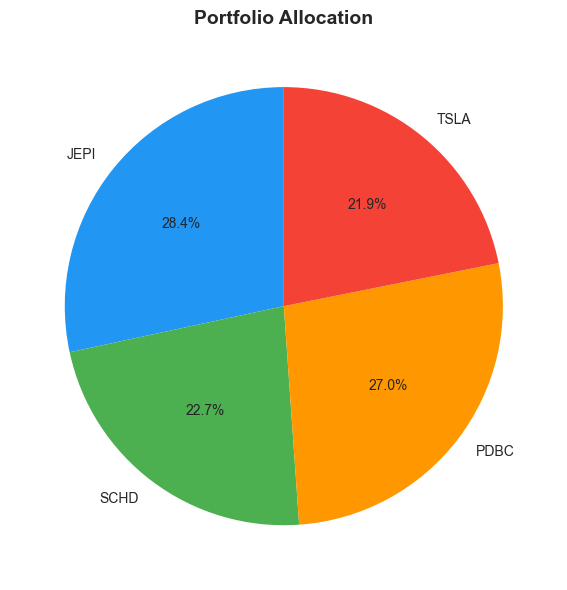

In [6]:
# 포트폴리오 비중 시각화
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
weights = market_value / total_value * 100

ax.pie(weights, 
       labels=tickers, 
       autopct='%1.1f%%',
       colors=colors,
       startangle=90)

ax.set_title('Portfolio Allocation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# 일별 수익률 계산
returns = prices.pct_change().dropna()

# 누적 수익률 계산
cumulative_returns = (1 + returns).cumprod() - 1

print("=== 기간 누적 수익률 ===")
for ticker in tickers:
    ret = cumulative_returns[ticker].iloc[-1] * 100
    print(f"{ticker}: {ret:+.1f}%")

=== 기간 누적 수익률 ===
JEPI: +7.3%
SCHD: +3.6%
PDBC: +0.6%
TSLA: +1.6%


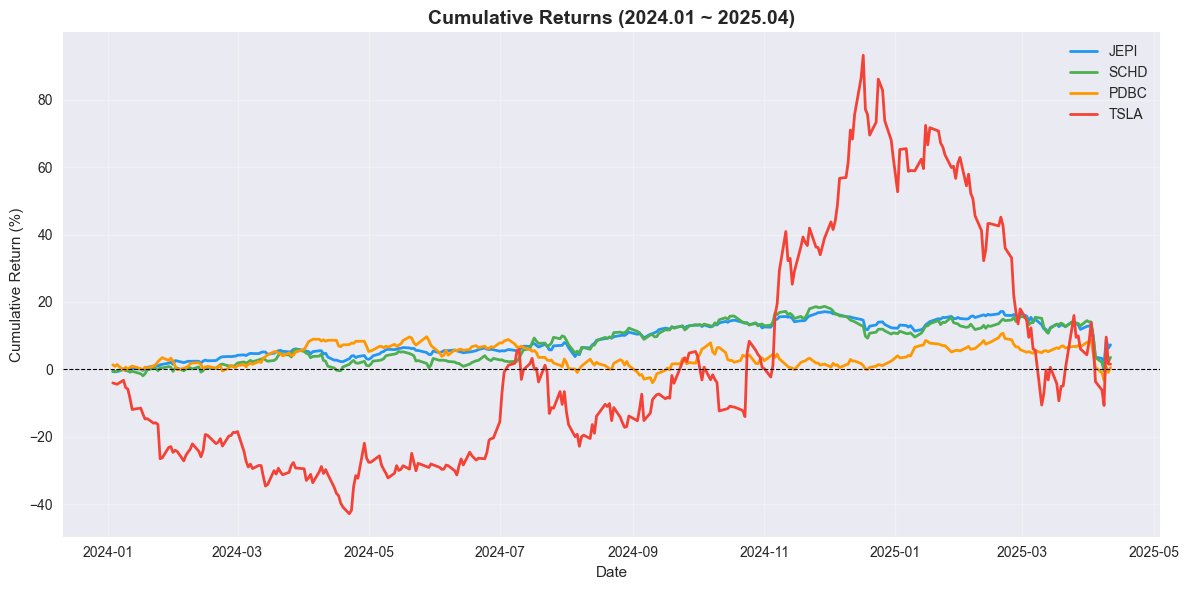

In [8]:
# 누적 수익률 라인차트
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

for ticker, color in zip(tickers, colors):
    ax.plot(cumulative_returns.index, 
            cumulative_returns[ticker] * 100,
            label=ticker,
            color=color,
            linewidth=2)

ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.set_title('Cumulative Returns (2024.01 ~ 2025.04)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# 리스크 분석
annual_return = returns.mean() * 252 * 100
annual_volatility = returns.std() * np.sqrt(252) * 100
sharpe_ratio = (returns.mean() * 252) / (returns.std() * np.sqrt(252))

print("=== 리스크 분석 ===")
print(f"{'종목':<8} {'연환산수익률':>12} {'연환산변동성':>12} {'샤프비율':>10}")
print("-" * 45)
for ticker in tickers:
    print(f"{ticker:<8} {annual_return[ticker]:>11.1f}% {annual_volatility[ticker]:>11.1f}% {sharpe_ratio[ticker]:>10.2f}")
    

=== 리스크 분석 ===
종목             연환산수익률       연환산변동성       샤프비율
---------------------------------------------
JEPI             6.3%        12.1%       0.52
SCHD             3.9%        14.8%       0.26
PDBC             1.5%        14.8%       0.10
TSLA            24.5%        69.1%       0.35


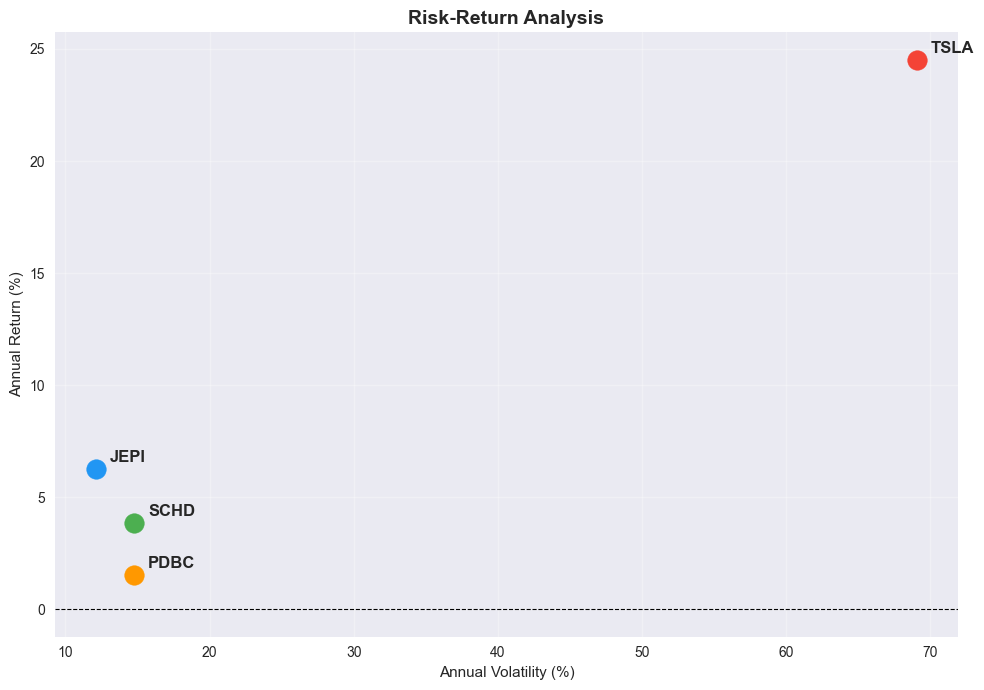

In [10]:
# 리스크-수익률 산점도
fig, ax = plt.subplots(figsize=(10, 7))

for ticker, color in zip(tickers, colors):
    ax.scatter(annual_volatility[ticker], 
               annual_return[ticker],
               s=200, color=color, zorder=5)
    ax.annotate(ticker, 
                (annual_volatility[ticker], annual_return[ticker]),
                textcoords="offset points",
                xytext=(10, 5),
                fontsize=12,
                fontweight='bold')

ax.set_title('Risk-Return Analysis', fontsize=14, fontweight='bold')
ax.set_xlabel('Annual Volatility (%)')
ax.set_ylabel('Annual Return (%)')
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# 포트폴리오 전체 성과
weights = market_value / total_value

portfolio_returns = (returns * weights).sum(axis=1)
cumulative_portfolio = (1 + portfolio_returns).cumprod() - 1

portfolio_annual_return = portfolio_returns.mean() * 252 * 100
portfolio_volatility = portfolio_returns.std() * np.sqrt(252) * 100
portfolio_sharpe = (portfolio_returns.mean() * 252) / (portfolio_returns.std() * np.sqrt(252))

print("=== 포트폴리오 전체 성과 ===")
print(f"연환산 수익률: {portfolio_annual_return:.1f}%")
print(f"연환산 변동성: {portfolio_volatility:.1f}%")
print(f"샤프비율: {portfolio_sharpe:.2f}")
print(f"누적 수익률: {cumulative_portfolio.iloc[-1]*100:.1f}%")

=== 포트폴리오 전체 성과 ===
연환산 수익률: 8.5%
연환산 변동성: 20.4%
샤프비율: 0.42
누적 수익률: 8.6%


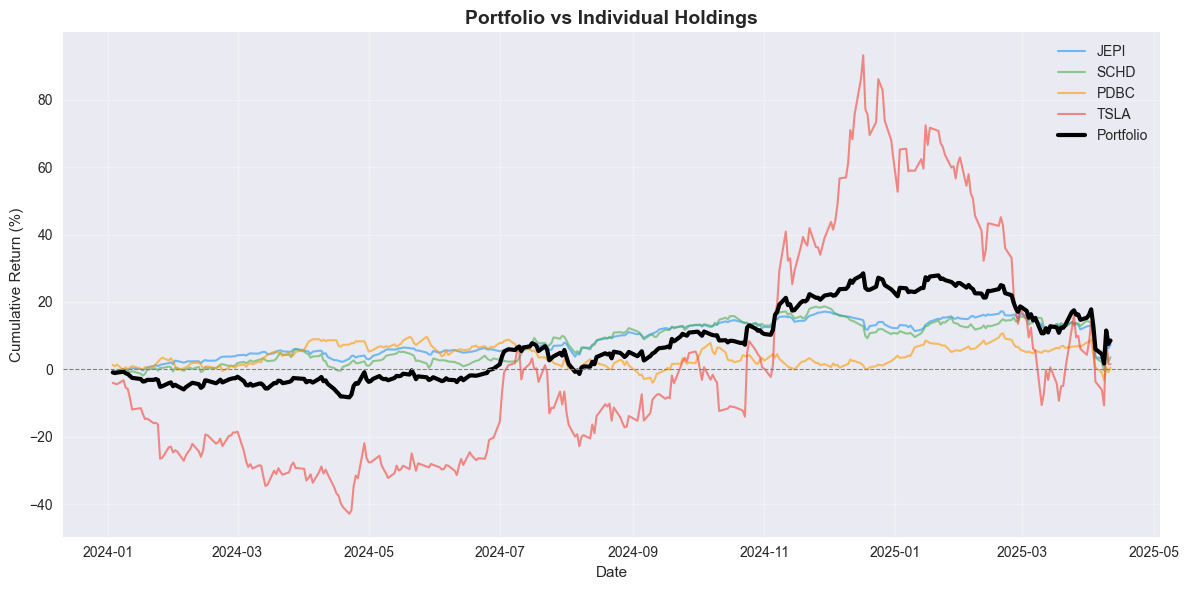

In [13]:
# 개별 종목 + 포트폴리오 전체 비교
fig, ax = plt.subplots(figsize=(12, 6))

for ticker, color in zip(tickers, colors):
    ax.plot(cumulative_returns.index,
            cumulative_returns[ticker] * 100,
            label=ticker,
            color=color,
            linewidth=1.5,
            alpha=0.6)

ax.plot(cumulative_portfolio.index,
        cumulative_portfolio * 100,
        label='Portfolio',
        color='black',
        linewidth=3)

ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Portfolio vs Individual Holdings', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()